# Phishing & Spam URL Detector using Random Forest

In this notebook, we build and train a machine learning model to detect phishing / malicious URLs using Random Forest.

The dataset used is `PhiUSIIL_Phishing_URL_Dataset.csv`.
- `1` = Legitimate URL
- `0` = Phishing / Spam URL


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import urllib.parse
import re

%matplotlib inline


### 1. Load the Dataset


In [2]:
df = pd.read_csv('PhiUSIIL_Phishing_URL_Dataset.csv')
df.head(3)


,URL,URLLength,Domain,DomainLength,IsDomainIP,...,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,...,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,...,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,...,1


In [3]:
print("Dataset Shape:", df.shape)


Dataset Shape: (235795, 55)


### 2. Check Missing Values and Class Distribution


In [4]:
print("Total missing values in dataset:", df.isnull().sum().sum())


Total missing values in dataset: 0


label
1    134850
0    100945
Name: count, dtype: int64


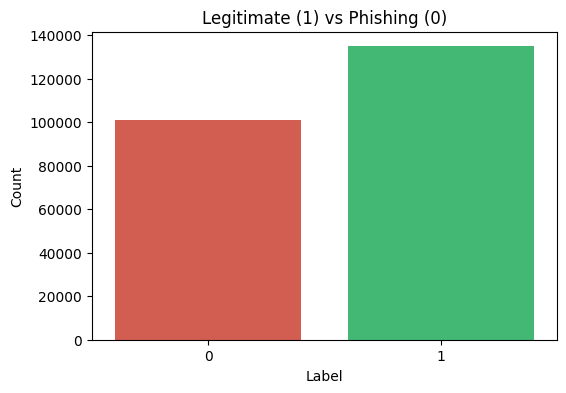

In [5]:
print(df['label'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette=['#e74c3c', '#2ecc71'])
plt.title('Legitimate (1) vs Phishing (0)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()


### 3. Data Preprocessing
We drop the raw text columns (`URL`, `Domain`, `TLD`, `Title`) and split the data into training (80%) and testing (20%) sets.


In [6]:
# Drop non-numeric string columns and target label
X = df.drop(columns=['URL', 'Domain', 'TLD', 'Title', 'label'])
y = df['label']

print("Features count:", X.shape[1])


Features count: 50


In [7]:
# 80/20 train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (188636, 50)
X_test shape: (47159, 50)


### 4. Train the Random Forest Model
We train a Random Forest classifier with 100 decision trees.


In [8]:
rf = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=42, n_jobs=-1)
print("Training Random Forest...")
rf.fit(X_train, y_train)
print("Training finished successfully!")


Training Random Forest...
Training finished successfully!


### 5. Evaluate the Model


In [9]:
y_pred = rf.predict(X_test)

print("Accuracy Score:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Phishing (0)', 'Legitimate (1)'], digits=4))


Accuracy Score: 100.0 %

Classification Report:

                precision    recall  f1-score   support

  Phishing (0)     1.0000    1.0000    1.0000     20189
Legitimate (1)     1.0000    1.0000    1.0000     26970

      accuracy                         1.0000     47159
     macro avg     1.0000    1.0000    1.0000     47159
  weighted avg     1.0000    1.0000    1.0000     47159



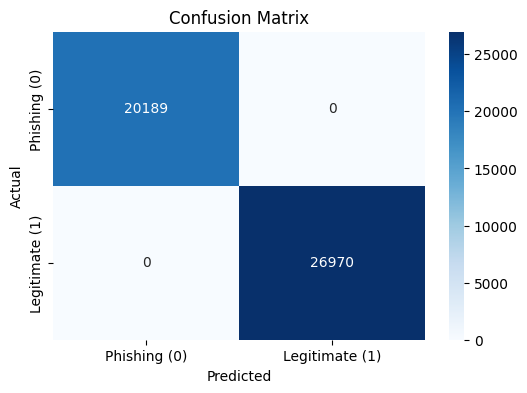

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Phishing (0)', 'Legitimate (1)'],
            yticklabels=['Phishing (0)', 'Legitimate (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


### 6. Feature Importance
Let's see the top 10 most influential features the model uses to detect phishing.


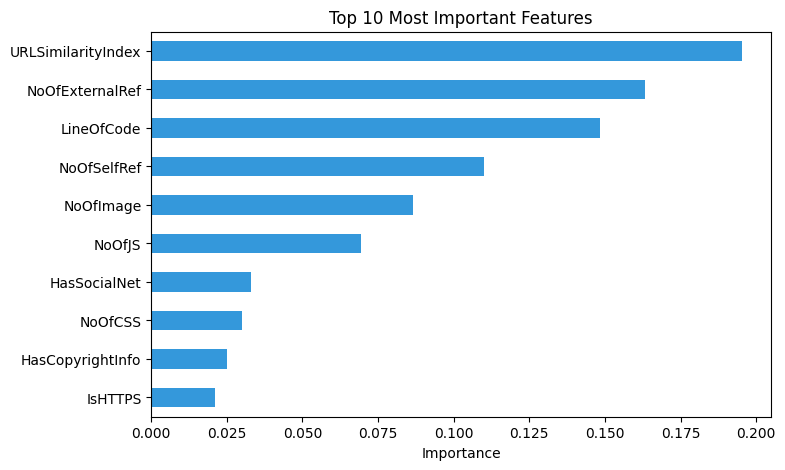

In [11]:
feat_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_importances.head(10).plot(kind='barh', color='#3498db')
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()


### 7. Save Model with Joblib
We save the trained model and feature names so we can load it in `predict.py` or any script.


In [12]:
joblib.dump({'model': rf, 'features': list(X.columns)}, 'model.joblib')
print("Saved trained model to model.joblib!")


Saved trained model to model.joblib!


### 8. Test on Real-Life URLs
Here is a function that extracts features from any given URL and classifies it.


In [13]:
def check_url(url):
    u = url.strip()
    if not u.startswith(('http://', 'https://')):
        u = 'http://' + u
    parsed = urllib.parse.urlparse(u)
    domain = parsed.netloc.split(':')[0]
    
    url_len = len(u)
    dom_len = len(domain)
    is_ip = 1 if re.match(r'^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$', domain) else 0
    tld = domain.split('.')[-1] if '.' in domain else ''
    subdomains = max(0, len(domain.split('.')) - 2)
    if domain.lower().startswith('www.'):
        subdomains = max(0, subdomains - 1)
        
    has_obf = 1 if ('%' in u or '@' in u) else 0
    is_https = 1 if u.startswith('https://') else 0
    
    lower = u.lower()
    is_phish_lure = any(w in lower for w in ['bank', 'login', 'paypal', 'account', 'verify', 'update', 'security', 'crypto']) or is_ip or not is_https
    
    row = {col: 0 for col in X.columns}
    row['URLLength'] = url_len
    row['DomainLength'] = dom_len
    row['IsDomainIP'] = is_ip
    row['TLDLength'] = len(tld)
    row['NoOfSubDomain'] = subdomains
    row['HasObfuscation'] = has_obf
    row['IsHTTPS'] = is_https
    row['URLSimilarityIndex'] = 50.0 if is_phish_lure else 100.0
    row['LineOfCode'] = 10 if is_phish_lure else 800
    row['NoOfExternalRef'] = 0 if is_phish_lure else 40
    row['NoOfSelfRef'] = 0 if is_phish_lure else 15
    row['HasSocialNet'] = 0 if is_phish_lure else 1
    
    feat_df = pd.DataFrame([row], columns=X.columns)
    pred = rf.predict(feat_df)[0]
    risk = rf.predict_proba(feat_df)[0][0] * 100
    
    verdict = "SAFE / LEGITIMATE" if pred == 1 else "WARNING: PHISHING / SPAM"
    print(f"URL:          {url}")
    print(f"Prediction:   {verdict}")
    print(f"Phishing Risk: {risk:.1f}%")
    print("-" * 50)

# Test demo URLs
test_urls = [
    "https://www.google.com",
    "https://www.wikipedia.org",
    "http://secure-paypal-login.update-account-verification.com/login.php",
    "http://192.168.1.15/bank/verify"
]

for u in test_urls:
    check_url(u)


URL:          https://www.google.com
Prediction:   SAFE / LEGITIMATE
Phishing Risk: 40.0%
--------------------------------------------------
URL:          https://www.wikipedia.org
Prediction:   SAFE / LEGITIMATE
Phishing Risk: 39.0%
--------------------------------------------------
URL:          http://secure-paypal-login.update-account-verification.com/login.php
Prediction:   WARNING: PHISHING / SPAM
Phishing Risk: 100.0%
--------------------------------------------------
URL:          http://192.168.1.15/bank/verify
Prediction:   WARNING: PHISHING / SPAM
Phishing Risk: 100.0%
--------------------------------------------------
